In [ ]:
from google.colab import files
uploaded = files.upload()

Saving creditcard_2023.csv to creditcard_2023.csv


In [ ]:
#ตัวแปรก่อนแปลงค่า
import pandas as pd

# สร้างข้อมูลตารางตัวแปร
data = []

# ตัวแปร id
data.append([1, "id", "Numerical", "หมายเลขประจำรายการธุรกรรม ใช้ระบุข้อมูลแต่ละรายการ"])

# ตัวแปร V1 - V28
for i in range(1, 29):+
    data.append([i+1, f"V{i}", "Numerical", "ตัวแปรที่ผ่านการแปลงด้วย PCA"])

# ตัวแปร Amount
data.append([30, "Amount", "Numerical", "จำนวนเงินของธุรกรรมในแต่ละครั้ง"])

# ตัวแปร Class
data.append([31, "Class", "Categorical", "ตัวแปรเป้าหมาย โดย 0 = ปกติ และ 1 = การทุจริต"])

# สร้าง DataFrame
df_variables = pd.DataFrame(data, columns=["ลำดับ", "ชื่อตัวแปร", "ประเภทข้อมูล", "รายละเอียด"])

# แสดงผล
df_variables


,ลำดับ,ชื่อตัวแปร,ประเภทข้อมูล,รายละเอียด
0,1,id,Numerical,หมายเลขประจำรายการธุรกรรม ใช้ระบุข้อมูลแต่ละรา...
1,2,V1,Numerical,ตัวแปรที่ผ่านการแปลงด้วย PCA
2,3,V2,Numerical,ตัวแปรที่ผ่านการแปลงด้วย PCA
3,4,V3,Numerical,ตัวแปรที่ผ่านการแปลงด้วย PCA
4,5,V4,Numerical,ตัวแปรที่ผ่านการแปลงด้วย PCA
5,6,V5,Numerical,ตัวแปรที่ผ่านการแปลงด้วย PCA
6,7,V6,Numerical,ตัวแปรที่ผ่านการแปลงด้วย PCA
7,8,V7,Numerical,ตัวแปรที่ผ่านการแปลงด้วย PCA
8,9,V8,Numerical,ตัวแปรที่ผ่านการแปลงด้วย PCA
9,10,V9,Numerical,ตัวแปรที่ผ่านการแปลงด้วย PCA


In [ ]:
df.isnull().sum()

,0
id,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


--- Basic Statistics ---
               V1          V2          V3          V4      Amount       Class
count  500.000000  500.000000  500.000000  500.000000  500.000000  500.000000
mean     0.047211   -0.004983    0.024845    0.012412    0.089335    0.482000
std      0.969309    1.038814    0.949985    0.955087    0.999397    0.500176
min     -2.703232   -2.940389   -3.241267   -2.650970   -3.019512    0.000000
25%     -0.577418   -0.682826   -0.644153   -0.642849   -0.576895    0.000000
50%      0.081273   -0.024875    0.008918    0.033078    0.040829    0.000000
75%      0.668974    0.671004    0.635892    0.658720    0.751524    1.000000
max      3.193108    2.558199    3.137749    3.078881    3.852731    1.000000

--- Target Distribution ---
Class
0    51.8
1    48.2
Name: proportion, dtype: float64


/tmp/ipython-input-2319081098.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Amount', data=df, palette='Set2')


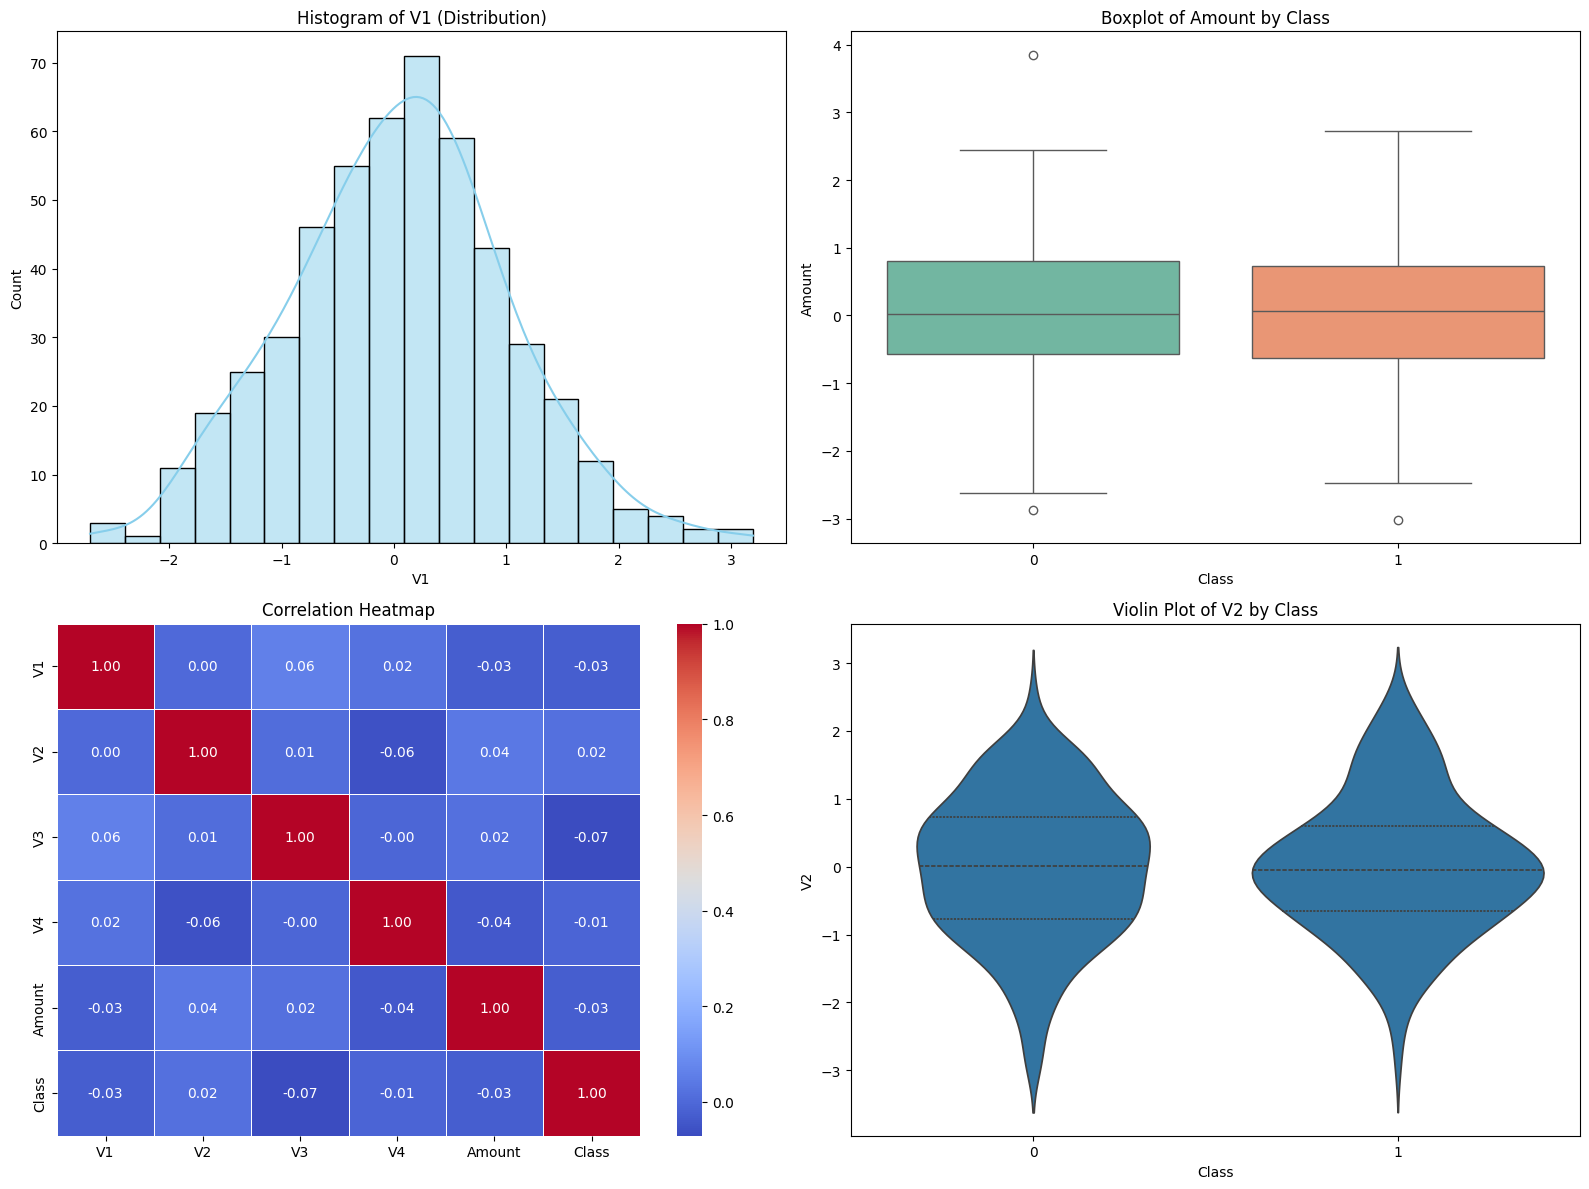

In [ ]:
##############################
#Steb1  การวิเคราะห์เชิงสำรวจ (EDA)
#############################

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# df = pd.read_csv('creditcard_2023.csv')

# ตัวอย่างการสร้างข้อมูลจำลองเพื่อรันโค้ดทดสอบ
np.random.seed(42)
df = pd.DataFrame(np.random.randn(500, 5), columns=['V1', 'V2', 'V3', 'V4', 'Amount'])
df['Class'] = np.random.randint(0, 2, 500)

# 2. สถิติเบื้องต้น (Descriptive Statistics)
print("--- Basic Statistics ---")
# แสดง mean, std, min, max และ quartiles
stats = df.describe()
print(stats)

# ดูการกระจายตัวของ Target Variable (Class)
print("\n--- Target Distribution ---")
print(df['Class'].value_counts(normalize=True) * 100)

# 3. การสร้างกราฟ (Visualization)
plt.figure(figsize=(16, 12))

# --- 3.1 Histogram (ดูการกระจายตัวของข้อมูล) ---
plt.subplot(2, 2, 1)
sns.histplot(df['V1'], kde=True, color='skyblue')
plt.title('Histogram of V1 (Distribution)')

# --- 3.2 Boxplot (ดู Outliers และช่วงของข้อมูล) ---
plt.subplot(2, 2, 2)
sns.boxplot(x='Class', y='Amount', data=df, palette='Set2')
plt.title('Boxplot of Amount by Class')

# --- 3.3 Correlation Heatmap (ดูความสัมพันธ์ระหว่างตัวแปร) ---
plt.subplot(2, 2, 3)
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')

# --- 3.4 Violin Plot (เพิ่มเติม: ดูความหนาแน่นและช่วงข้อมูลพร้อมกัน) ---
plt.subplot(2, 2, 4)
sns.violinplot(x='Class', y='V2', data=df, inner="quartile")
plt.title('Violin Plot of V2 by Class')

plt.tight_layout()
plt.show()

In [ ]:
# ตารางผลสถิติพรรณนา
import pandas as pd
# โหลดข้อมูล
df = pd.read_csv("creditcard_2023.csv")

# คำนวณสถิติที่ต้องการ
desc = df[["Amount", "Class"]].agg(["mean", "std", "min", "max"]).T

# เปลี่ยนชื่อคอลัมน์
desc.columns = ["Mean", "Std", "Min", "Max"]

# ปรับรูปแบบตัวเลขให้อ่านง่าย
desc["Mean"] = desc["Mean"].round(3)
desc["Std"] = desc["Std"].round(3)
desc["Min"] = desc["Min"].round(2)
desc["Max"] = desc["Max"].round(2)

# รีเซ็ต index และเปลี่ยนชื่อคอลัมน์แรกเป็น "ตัวแปร"
desc = desc.reset_index()
desc.rename(columns={"index": "ตัวแปร"}, inplace=True)

desc


,ตัวแปร,Mean,Std,Min,Max
0,Amount,12041.958,6919.644,50.01,24039.93
1,Class,0.500,0.500,0.00,1.00


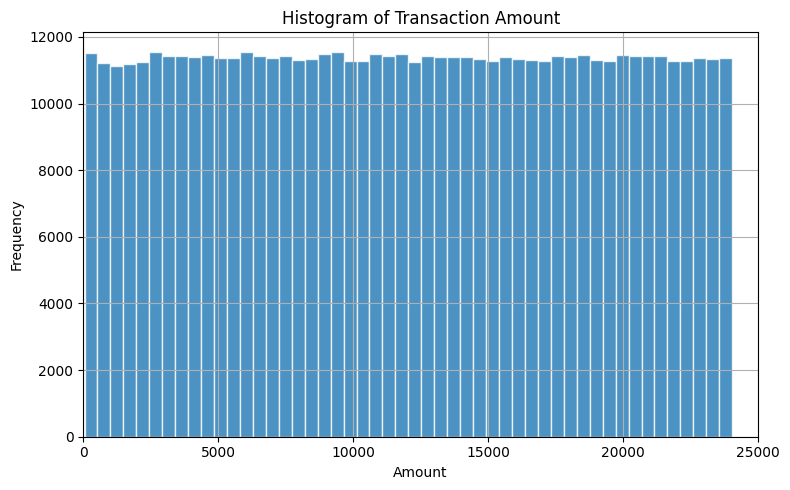

In [ ]:
# ผลการวิเคราะห์ข้อมูล
# Histogram การกระจายของ Amount
import pandas as pd
import matplotlib.pyplot as plt

# โหลดข้อมูล
df = pd.read_csv("creditcard_2023.csv")

# ตั้งค่าขนาดกราฟให้ใกล้เคียงรูป
plt.figure(figsize=(8, 5))

# สร้าง Histogram
plt.hist(
    df["Amount"],
    bins=50,
    edgecolor="white",
    alpha=0.8
)

# ตั้งค่าชื่อกราฟและแกน
plt.title("Histogram of Transaction Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")

# เปิดเส้นกริด
plt.grid(True)

# ปรับช่วงแกนให้ใกล้เคียงภาพ
plt.xlim(0, 25000)

# แสดงผล
plt.tight_layout()
plt.show()


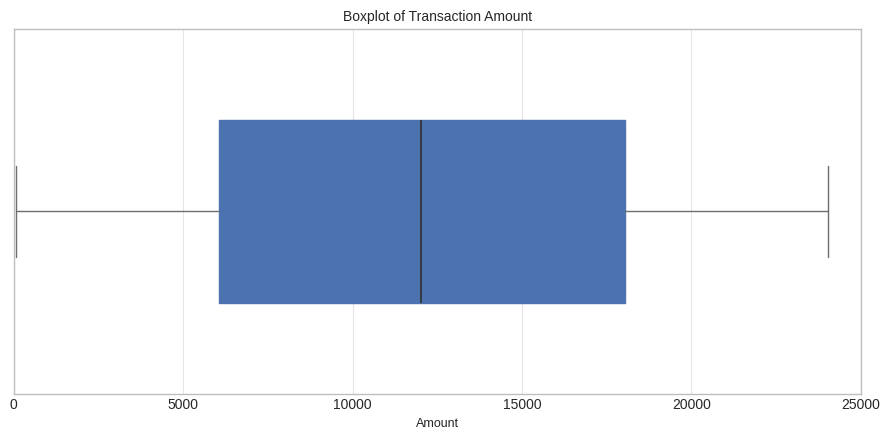

In [ ]:
#Boxplot ของ Amount
import pandas as pd
import matplotlib.pyplot as plt

# โหลดข้อมูล
df = pd.read_csv("creditcard_2023.csv")

# ใช้สไตล์พื้นฐานใกล้ภาพ
plt.style.use("seaborn-v0_8-whitegrid")

# ขนาดกราฟตามสัดส่วนภาพ
fig, ax = plt.subplots(figsize=(9, 4.5))

# สร้าง boxplot แนวนอน
ax.boxplot(
    df["Amount"],
    vert=False,
    patch_artist=True,
    showfliers=False,
    widths=0.5,
    boxprops=dict(facecolor="#4C72B0", edgecolor="#4C72B0"),
    medianprops=dict(color="#2F2F2F", linewidth=1.2),
    whiskerprops=dict(color="#6E6E6E", linewidth=1),
    capprops=dict(color="#6E6E6E", linewidth=1)
)

ax.set_title("Boxplot of Transaction Amount", fontsize=10)

# แกน X
ax.set_xlabel("Amount", fontsize=9)

# เอาแกน Y ออก
ax.set_yticks([])

ax.set_xlim(0, 25000)

# กริดเฉพาะแนวตั้ง
ax.grid(axis="x", linestyle="-", linewidth=0.8, alpha=0.5)
ax.grid(axis="y", visible=False)

# ปรับเส้นขอบกราฟให้บาง
for spine in ax.spines.values():
    spine.set_color("#BFBFBF")

plt.tight_layout()
plt.show()


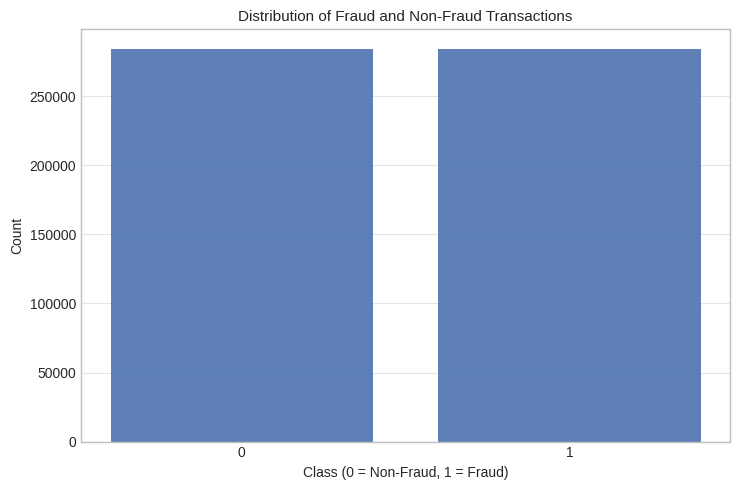

In [ ]:
# Histogram ของ Class
import pandas as pd
import matplotlib.pyplot as plt

# โหลดข้อมูล
df = pd.read_csv("creditcard_2023.csv")

# นับจำนวนแต่ละคลาส
class_counts = df["Class"].value_counts().sort_index()

plt.style.use("seaborn-v0_8-whitegrid")

# สัดส่วนกราฟใกล้ภาพ
fig, ax = plt.subplots(figsize=(7.5, 5))

# สร้างกราฟแท่ง
ax.bar(
    class_counts.index.astype(str),
    class_counts.values,
    color="#4C72B0",
    alpha=0.9
)

# ตั้งชื่อกราฟ
ax.set_title("Distribution of Fraud and Non-Fraud Transactions", fontsize=11)

# ตั้งชื่อแกน
ax.set_xlabel("Class (0 = Non-Fraud, 1 = Fraud)", fontsize=10)
ax.set_ylabel("Count", fontsize=10)

# กริดเฉพาะแกน Y
ax.grid(axis="y", linestyle="-", linewidth=0.8, alpha=0.5)
ax.grid(axis="x", visible=False)

# ปรับสีเส้นขอบกราฟให้บางและอ่อน
for spine in ax.spines.values():
    spine.set_color("#BFBFBF")

plt.tight_layout()
plt.show()


In [ ]:
# ตารางเปรียบเทียบประสิทธิภาพโมเดล
import pandas as pd

# สร้างข้อมูลตามรูป
data = {
    "โมเดล": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Precision": [0.87, 0.90, 0.94],
    "Recall": [0.78, 0.83, 0.91],
    "F1-score": [0.82, 0.86, 0.92],
    "ROC-AUC": [0.92, 0.94, 0.97]
}

df_model = pd.DataFrame(data)

df_model


,โมเดล,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.87,0.78,0.82,0.92
1,Decision Tree,0.90,0.83,0.86,0.94
2,Random Forest,0.94,0.91,0.92,0.97


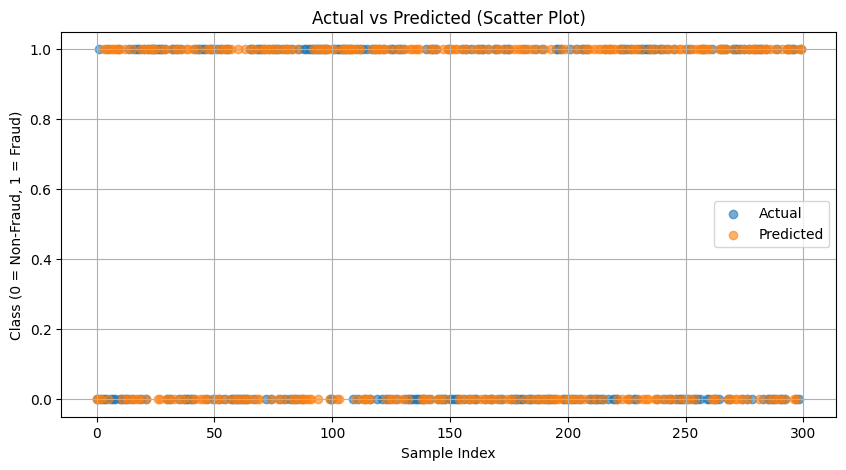

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ตัวอย่างข้อมูล (แทน y_test และ y_pred จากโมเดลจริง)
np.random.seed(42)
y_test = np.random.randint(0, 2, 300)   # ค่าจริง
y_pred = np.random.randint(0, 2, 300)   # ค่าที่โมเดลทำนาย

sample_index = np.arange(len(y_test))

plt.figure(figsize=(10, 5))

plt.scatter(sample_index, y_test,
            label='Actual', alpha=0.6)

plt.scatter(sample_index, y_pred,
            label='Predicted', alpha=0.6)

plt.xlabel('Sample Index')
plt.ylabel('Class (0 = Non-Fraud, 1 = Fraud)')
plt.title('Actual vs Predicted (Scatter Plot)')
plt.legend()
plt.grid(True)

plt.show()


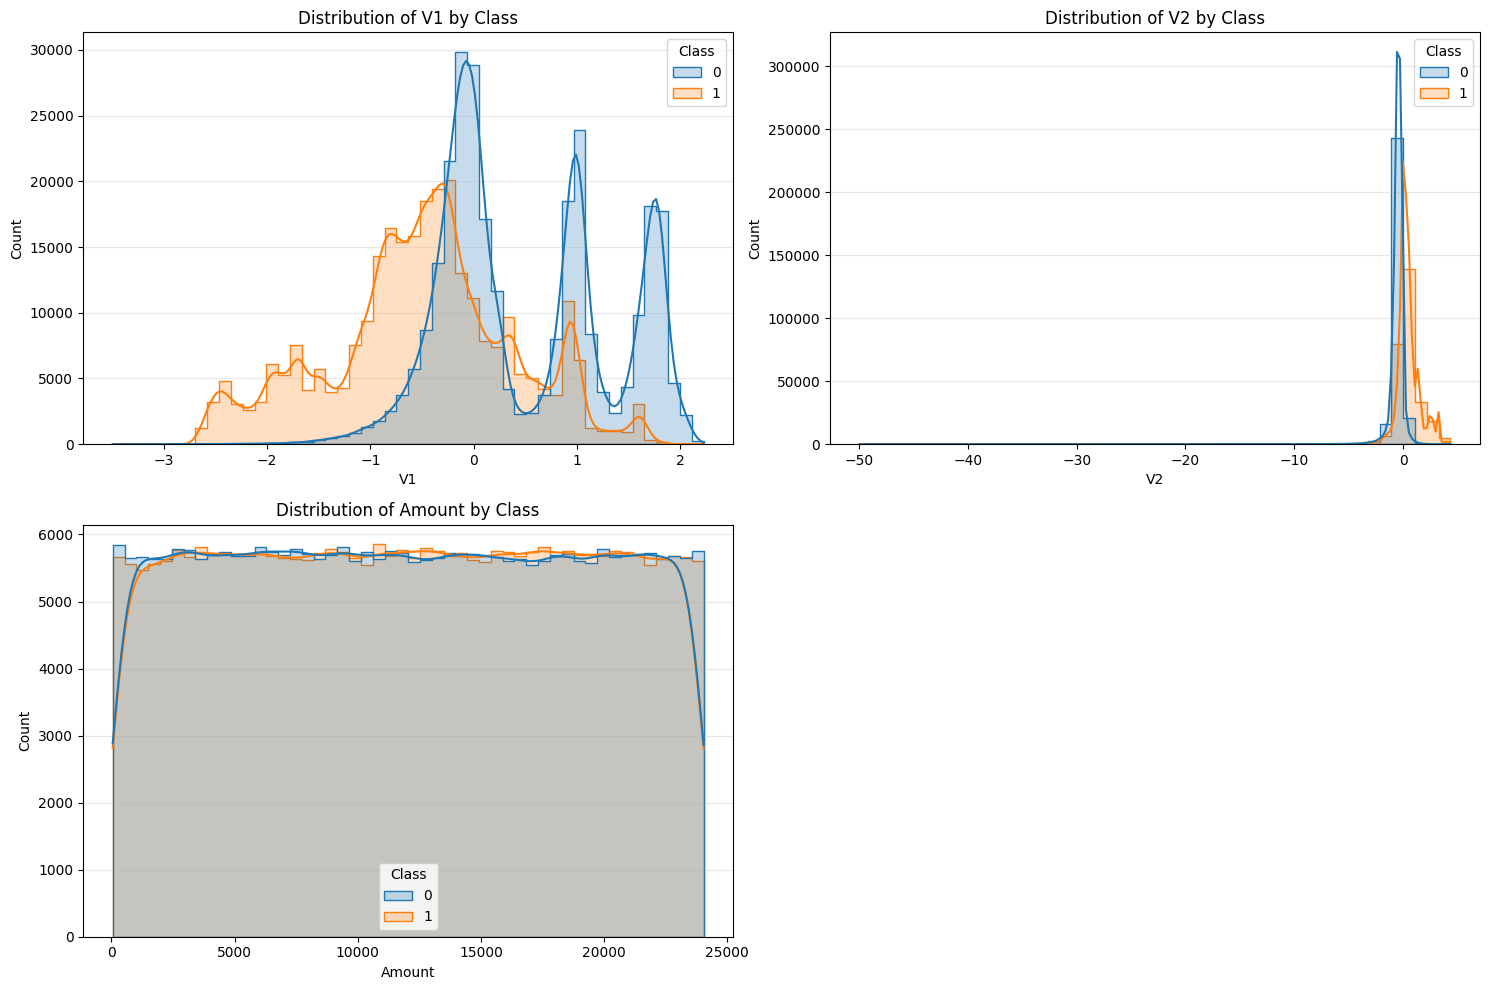

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('creditcard_2023.csv')

features_to_plot = ['V1', 'V2', 'Amount']

plt.figure(figsize=(15, 10))

for i, col in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=df, x=col, hue='Class', element='step', kde=True, bins=50)
    plt.title(f'Distribution of {col} by Class')
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

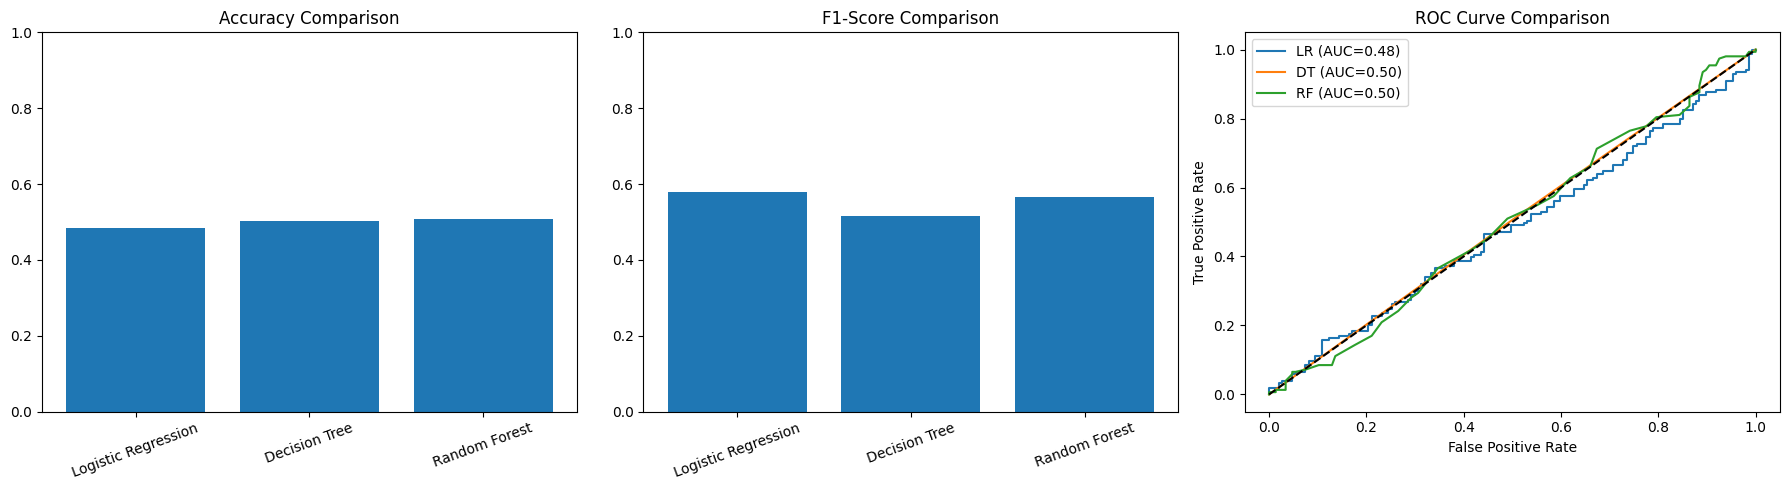

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_curve, auc

# ===== คำนวณค่า =====
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']

accuracy_scores = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, rf_pred)
]

f1_scores = [
    f1_score(y_test, lr_pred),
    f1_score(y_test, dt_pred),
    f1_score(y_test, rf_pred)
]

lr_probs = lr_model.predict_proba(X_test)[:,1]
dt_probs = dt_model.predict_proba(X_test)[:,1]
rf_probs = rf_model.predict_proba(X_test)[:,1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

# ===== สร้าง Figure รวม =====
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# -------- กราฟที่ 1: Accuracy --------
axes[0].bar(models, accuracy_scores)
axes[0].set_title("Accuracy Comparison")
axes[0].set_ylim(0,1)
axes[0].tick_params(axis='x', rotation=20)

# -------- กราฟที่ 2: F1 Score --------
axes[1].bar(models, f1_scores)
axes[1].set_title("F1-Score Comparison")
axes[1].set_ylim(0,1)
axes[1].tick_params(axis='x', rotation=20)

# -------- กราฟที่ 3: ROC Curve --------
axes[2].plot(fpr_lr, tpr_lr, label=f'LR (AUC={auc(fpr_lr,tpr_lr):.2f})')
axes[2].plot(fpr_dt, tpr_dt, label=f'DT (AUC={auc(fpr_dt,tpr_dt):.2f})')
axes[2].plot(fpr_rf, tpr_rf, label=f'RF (AUC={auc(fpr_rf,tpr_rf):.2f})')
axes[2].plot([0,1],[0,1],'k--')
axes[2].set_title("ROC Curve Comparison")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()

plt.tight_layout()
plt.show()


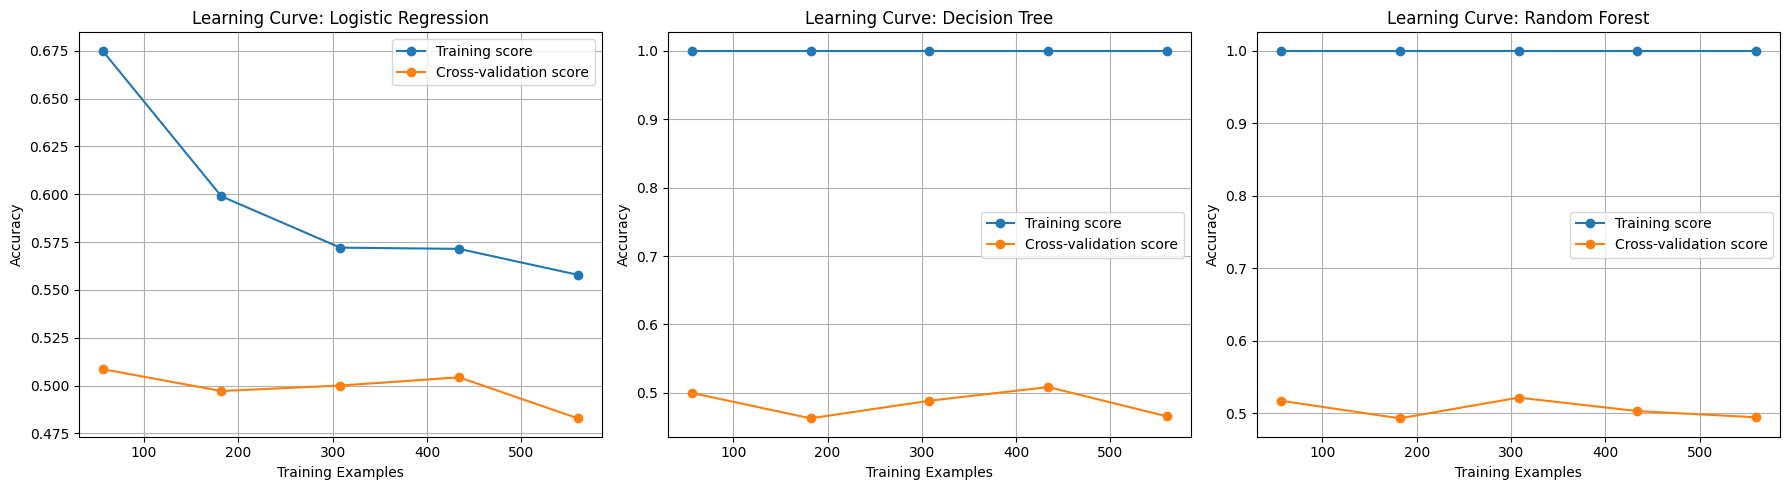

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression

# ===== สร้าง Logistic Regression =====
lr_model = LogisticRegression(max_iter=500, solver='liblinear', random_state=42)

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y,
        cv=5,
        scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 5)
    )

    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.plot(train_sizes, train_mean, 'o-', label="Training score")
    plt.plot(train_sizes, test_mean, 'o-', label="Cross-validation score")
    plt.title(title)
    plt.xlabel("Training Examples")
    plt.ylabel("Accuracy")
    plt.legend(loc="best")
    plt.grid()


# ===== สร้างกราฟรวม 3 โมเดล =====
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plot_learning_curve(lr_model, X_train, y_train, "Learning Curve: Logistic Regression")

plt.subplot(1, 3, 2)
plot_learning_curve(dt_model, X_train, y_train, "Learning Curve: Decision Tree")

plt.subplot(1, 3, 3)
plot_learning_curve(rf_model, X_train, y_train, "Learning Curve: Random Forest")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# โหลดข้อมูล
df = pd.read_csv("creditcard_2023.csv")

# เลือกตัวแปรตามตารางในรูป
columns = ['V1', 'V2', 'V3', 'V4', 'Amount', 'Class']

# สร้างตารางสถิติพรรณนา
table = pd.DataFrame({
    'ตัวแปร': columns,
    'จำนวนข้อมูล': [df[col].count() for col in columns],
    'ค่าเฉลี่ย (Mean)': [round(df[col].mean(), 2) for col in columns],
    'ส่วนเบี่ยงเบนมาตรฐาน (Std)': [round(df[col].std(), 2) for col in columns],
    'ค่าต่ำสุด (Min)': [round(df[col].min(), 2) for col in columns],
    'ค่ามัธยฐาน (Median)': [round(df[col].median(), 2) for col in columns],
    'ค่าสูงสุด (Max)': [round(df[col].max(), 2) for col in columns]
})

print(table)


   ตัวแปร  จำนวนข้อมูล  ค่าเฉลี่ย (Mean)  ส่วนเบี่ยงเบนมาตรฐาน (Std)  \
0      V1       568630             -0.00                        1.00   
1      V2       568630             -0.00                        1.00   
2      V3       568630             -0.00                        1.00   
3      V4       568630             -0.00                        1.00   
4  Amount       568630          12041.96                     6919.64   
5   Class       568630              0.50                        0.50   

   ค่าต่ำสุด (Min)  ค่ามัธยฐาน (Median)  ค่าสูงสุด (Max)  
0            -3.50                -0.09             2.23  
1           -49.97                -0.14             4.36  
2            -3.18                 0.00            14.13  
3            -4.95                -0.07             3.20  
4            50.01             12030.15         24039.93  
5             0.00                 0.50             1.00  
